In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot as plt

In [3]:
import seaborn as sns

In [39]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

# clean our data
    in this module i learned:
        1. ffill
            ffill fills in the nan value by looking at the previous value 
        2. bfill
            bfill fills in the nan value by looking at the next observed value

In [40]:
df_train.isnull().sum()
#etract passenger group id
df_train['Group'] = df_train.PassengerId.str.split('_').str[0]
#now that we have that we can fill in the missing data based on group
df_train.HomePlanet = df_train.groupby('Group')['HomePlanet'].transform(lambda x: x.ffill().bfill())
df_train.isnull().sum()

C:\Users\chris\AppData\Local\Temp\ipykernel_31760\2547502912.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train.HomePlanet = df_train.groupby('Group')['HomePlanet'].transform(lambda x: x.ffill().bfill())


PassengerId       0
HomePlanet      111
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
Group             0
dtype: int64

In [41]:
df_train.head(50)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Group
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0001
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,0002
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,0003
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,0003
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,0004
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True,0005
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True,0006
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True,0006
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True,0007
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True,0008


In [42]:
#let's replace our home values with the most common one
df_train.HomePlanet.fillna(df_train.HomePlanet.mode()[0],inplace=True)
df_train.isnull().sum()

C:\Users\chris\AppData\Local\Temp\ipykernel_31760\2804298762.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train.HomePlanet.fillna(df_train.HomePlanet.mode()[0],inplace=True)


PassengerId       0
HomePlanet        0
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
Group             0
dtype: int64

<Axes: xlabel='Age', ylabel='Count'>

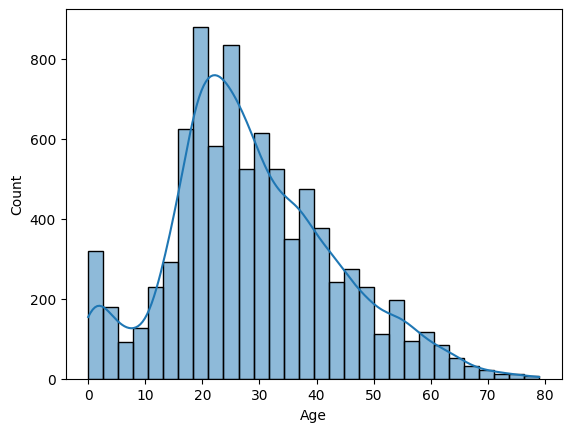

In [43]:
sns.histplot(df_train.Age,bins = 30, kde = True)

In [44]:
#let's replace the age nan values with the median by planet
df_train.Age = df_train.groupby('HomePlanet')['Age'].transform(lambda x: x.fillna(x.median()))
df_train.isnull().sum()

PassengerId       0
HomePlanet        0
CryoSleep       217
Cabin           199
Destination     182
Age               0
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
Group             0
dtype: int64

In [45]:
df_train.CryoSleep.isna().sum()

np.int64(217)

In [36]:
df_train.CryoSleep.isna().mean() * 100

np.float64(2.4962613597147127)

In [48]:
fill_cols = ['RoomService','FoodCourt','ShoppingMal','Spa','VRDeck']
df_train.fillna({'RoomService':0,'FoodCourt':0,'ShoppingMall':0,'Spa':0,'VRDeck':0},inplace = True)
df_train.isnull().sum()
df_train['TotalSpent'] = df_train.RoomService + df_train.FoodCourt+df_train.ShoppingMall+df_train.Spa+df_train.VRDeck

In [49]:
df_train.head(25)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Group,TotalSpent
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0001,0.0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,0002,736.0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,0003,10383.0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,0003,5176.0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,0004,1091.0
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True,0005,774.0
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True,0006,1584.0
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,0.0,Candra Jacostaffey,True,0006,0.0
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True,0007,1018.0
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True,0008,0.0


In [50]:
#replace cryosleep nan with true if the totalspent == 0
df_train.loc[df_train.TotalSpent==0,'CryoSleep'] = True #find where totalspent is 0 and set cryosleep to 0
df_train.isnull().sum() #check

PassengerId       0
HomePlanet        0
CryoSleep       119
Cabin           199
Destination     182
Age               0
VIP             203
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
Group             0
TotalSpent        0
dtype: int64

In [51]:
#still have some nan cryosleep values so to fix that we will replace with first mode
df_train.CryoSleep.fillna(df_train.CryoSleep.mode()[0],inplace = True)
df_train.isnull().sum() #check and all done

C:\Users\chris\AppData\Local\Temp\ipykernel_31760\496105277.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train.CryoSleep.fillna(df_train.CryoSleep.mode()[0],inplace = True)
C:\Users\chris\AppData\Local\Temp\ipykernel_31760\496105277.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train.CryoSlee

PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin           199
Destination     182
Age               0
VIP             203
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
Group             0
TotalSpent        0
dtype: int64

In [52]:
df_train.groupby('VIP')['TotalSpent'].mean()

VIP
False    1371.504644
True     4425.477387
Name: TotalSpent, dtype: float64

In [53]:
df_train.TotalSpent.describe()

count     8693.000000
mean      1440.866329
std       2803.045694
min          0.000000
25%          0.000000
50%        716.000000
75%       1441.000000
max      35987.000000
Name: TotalSpent, dtype: float64

In [54]:
len(df_train[(df_train['TotalSpent']>=3000) & (df_train.VIP==True)]) #92 vip's spent more than 3000
len(df_train[(df_train['TotalSpent']<=3000) & (df_train.VIP == True)]) #107 vip's spent less than 3000
#so not a lot of VIP's spent more than 3000 

107

# questions
    the real question is how much money does a person have to spend to be classified as 'VIP' ? looing at our data we see the mean spenditure for a 
    VIP member is about $4425 while non vip spent about 1371 on average. 
    here is what i will do:
        if a person's spenditure is within 5% of the mean of a VIP's, we will claissify that person as VIP

In [55]:
#lets grab our tolerance 
vip_mean = (df_train.groupby('VIP')['TotalSpent'].mean())[True]
vip_mean
tolerance = vip_mean *0.2 #20% of mean
lower,upper = vip_mean - tolerance, vip_mean + tolerance
print(lower,upper)

3540.381909547739 5310.572864321608


In [57]:
#now we will apply this tolerance to our dataframe for our VIP nan's
test = df_train
mask =(
    df_train.VIP.isna() &
    (df_train.TotalSpent >=lower) &
    (df_train.TotalSpent<= upper)
) #this is the df we will be fixing nan values for
df_train.loc[mask,'VIP'] = True
df_train.isnull().sum()

PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin           199
Destination     182
Age               0
VIP             198
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
Group             0
TotalSpent        0
dtype: int64

In [ ]:
#how many VIP's are there?
len(df_train[df_train.VIP==True]) #204 total VIP's
#let's look at whether those made it out alive or not based on what we have so far
#lets make a bar chart but first turn our transported data into 1 or 0
df_train.Transported = df_train.Transported.astype(int) #1: true, 0: False
df_train.head(10)
#okay now lets look at a barchart 
df_train[df_train.VIP == True]['Transported'].value_counts() #79 Vip's got transported, 125 didnt
df_train[df_train.VIP == False]['Transported'].value_counts() # 4198 non VIP's got transported, 4093 didnt
#not a lot of VIP's on this ship is it even significant?

# Replace nan VIP values with mode
    ive determined VIP as a feature is insignificant so I will just set the nan values to the mode

In [58]:
df_train.VIP = df_train.VIP.fillna(df_train.VIP.mode()[0])
df_train.isnull().sum()

C:\Users\chris\AppData\Local\Temp\ipykernel_31760\1188107961.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train.VIP = df_train.VIP.fillna(df_train.VIP.mode()[0])


PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin           199
Destination     182
Age               0
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
Group             0
TotalSpent        0
dtype: int64

# What's left:
    great so all i have missing nan values are for Cabin, destination, and Names
    Name's might not be important for a predicting model so i will drop name

In [59]:
df_train = df_train.drop(['Name'],axis=1)

In [60]:
df_train.isnull().sum()


PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin           199
Destination     182
Age               0
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Transported       0
Group             0
TotalSpent        0
dtype: int64

In [61]:
df_train.VIP= df_train.VIP.astype(int)

In [62]:
df_train.CryoSleep = df_train.CryoSleep.astype(int)

In [ ]:
df_train.Destination.unique()

In [63]:
#let's find where the destination is NA and their corresponding groups
df_train[(df_train.Destination.isna())].head(60)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Group,TotalSpent
47,0045_02,Mars,1,F/10/P,NaN,19.0,0,0.0,0.0,0.0,0.0,0.0,True,0045,0.0
128,0138_02,Earth,0,E/5/P,NaN,34.0,0,0.0,22.0,0.0,564.0,207.0,False,0138,793.0
139,0152_01,Earth,0,F/32/P,NaN,41.0,0,0.0,0.0,0.0,0.0,607.0,False,0152,607.0
347,0382_01,Earth,0,G/64/P,NaN,23.0,0,348.0,0.0,0.0,4.0,368.0,False,0382,720.0
430,0462_01,Earth,1,G/67/S,NaN,50.0,0,0.0,0.0,0.0,0.0,0.0,False,0462,0.0
468,0504_03,Europa,1,B/19/S,NaN,24.0,0,0.0,0.0,0.0,0.0,0.0,True,0504,0.0
529,0564_03,Europa,0,B/24/P,NaN,28.0,0,0.0,410.0,2.0,1354.0,3695.0,False,0564,5461.0
540,0571_04,Europa,1,C/21/P,NaN,30.0,0,0.0,0.0,0.0,0.0,0.0,True,0571,0.0
547,0576_01,Earth,0,F/107/S,NaN,21.0,0,0.0,0.0,625.0,110.0,0.0,False,0576,735.0
570,0597_01,Earth,1,G/91/P,NaN,23.0,0,0.0,0.0,0.0,0.0,0.0,True,0597,0.0


In [64]:
df_train.loc[(df_train.PassengerId.str.split('_').str[1]=='02') & (df_train.Destination.isna())]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Group,TotalSpent
47,0045_02,Mars,1,F/10/P,NaN,19.0,0,0.0,0.0,0.0,0.0,0.0,True,0045,0.0
128,0138_02,Earth,0,E/5/P,NaN,34.0,0,0.0,22.0,0.0,564.0,207.0,False,0138,793.0
1660,1762_02,Earth,0,G/275/S,NaN,15.0,0,104.0,0.0,0.0,174.0,253.0,False,1762,531.0
2206,2361_02,Earth,0,F/481/P,NaN,29.0,0,0.0,0.0,792.0,0.0,0.0,True,2361,792.0
3440,3707_02,Earth,0,G/604/S,NaN,22.0,0,0.0,0.0,889.0,0.0,0.0,True,3707,889.0
3913,4181_02,Europa,1,C/133/P,NaN,0.0,0,0.0,0.0,0.0,0.0,0.0,True,4181,0.0
4128,4403_02,Earth,0,G/717/S,NaN,41.0,0,7.0,0.0,297.0,108.0,361.0,False,4403,773.0
4389,4662_02,Europa,1,C/148/P,NaN,53.0,0,0.0,0.0,0.0,0.0,0.0,True,4662,0.0
4450,4728_02,Mars,1,F/889/S,NaN,49.0,0,0.0,0.0,0.0,0.0,0.0,True,4728,0.0
4514,4796_02,Mars,1,E/311/S,NaN,43.0,0,0.0,0.0,0.0,0.0,0.0,True,4796,0.0


In [ ]:
df_train.Destination = df_train.groupby('Group')['Destination'].transform(lambda x: x.ffill().bfill())

In [ ]:
df_train.isnull().sum()

In [ ]:
lst = [df_train[df_train.Destination == 'TRAPPIST-1e']['HomePlanet'].value_counts(),df_train[df_train.Destination == 'PSO J318.5-22']['HomePlanet'].value_counts(),df_train[df_train.Destination == '55 Cancri e']['HomePlanet'].value_counts()]
lst

In [ ]:
dest_1 = df_train[df_train.Destination == 'TRAPPIST-1e']['HomePlanet'].value_counts()
#probabilities
#5967 across all planets went to trappist, lets break that down into percentages
trappist_earth = dest_1['Earth']/dest_1.sum() * 100
trappist_mars =  dest_1['Mars']/dest_1.sum() * 100
trappist_europa =  dest_1['Europa']/dest_1.sum() * 100

dest_2 = df_train[df_train.Destination == 'PSO J318.5-22']['HomePlanet'].value_counts()
pso_earth = dest_2['Earth']/dest_2.sum() * 100
pso_mars = dest_2['Mars']/dest_2.sum() * 100
pso_europa = dest_2['Europa']/dest_2.sum() * 100

dest_3 =df_train[df_train.Destination == '55 Cancri e']['HomePlanet'].value_counts()
cancri_earth = dest_3['Earth']/dest_3.sum() * 100
cancri_mars= dest_3['Mars']/dest_3.sum() * 100
cancri_europa= dest_3['Europa']/dest_3.sum() * 100



In [ ]:
df_train.Destination.unique()

In [ ]:
len(df_train[df_train.HomePlanet=='Europa']) #total number of europeans


# dev note
    i am finding the percentage of people that went to each detination. my next plan was to take the total number of poeple from europa, and divide it by the amount of people who went to trappist, then pso, then cancri. do this for all planets and i might get sime insight to who went where and who has the highest probability of going somewhere based on homeplanet

In [72]:
planet_dest_counts = pd.crosstab(df_train.HomePlanet,df_train.Destination,normalize = 'index') 

#now that we have our probability table we can start filling in nan values
#let's start with earth values
mask = (df_train.HomePlanet == 'Earth') & (df_train.Destination.isna())
df_train.loc[mask,'Destination'] = np.random.choice(['55 Cancri e','PSO J318.5-22','TRAPPIST-1e'],size=mask.sum(),p=[.153006,.157715,0.689279])#fill earth
df_train.isnull().sum()

PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin           199
Destination       0
Age               0
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Transported       0
Group             0
TotalSpent        0
dtype: int64

In [65]:
planet_dest_counts

Destination,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
HomePlanet,,,
Earth,0.153007,0.157715,0.689279
Europa,0.421911,0.008858,0.569231
Mars,0.111174,0.028217,0.860609


In [ ]:
listplanet_dest_counts['TRAPPIST-1e']

In [69]:
mask = (df_train.HomePlanet == 'Mars') & (df_train.Destination.isna())
df_train.loc[mask,'Destination'] = np.random.choice(['55 Cancri e','PSO J318.5-22','TRAPPIST-1e'],size=mask.sum(),p=[0.111174,0.028217,0.860609])

In [70]:
mask = (df_train.HomePlanet == 'Europa') & (df_train.Destination.isna())
df_train.loc[mask,'Destination'] = np.random.choice(['55 Cancri e','PSO J318.5-22','TRAPPIST-1e'],size=mask.sum(),p=[0.42191 ,0.008858,0.569232])

In [73]:
df_train.isnull().sum()

PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin           199
Destination       0
Age               0
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Transported       0
Group             0
TotalSpent        0
dtype: int64

In [74]:
df_train.to_csv('cleaned_train.csv',index = False)

# Handling HomePlanet and Destination
    one mehthd of doing this is using a One-Hot Encoding which is most common

In [4]:
df_encoding = pd.read_csv('cleaned_train.csv')

In [5]:
df_encoding = pd.get_dummies(df_encoding,columns=['HomePlanet','Destination'],drop_first = True)

In [6]:
df_encoding

,PassengerId,CryoSleep,Cabin,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Group,TotalSpent,HomePlanet_Europa,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0001_01,1,B/0/P,39.0,0,0.0,0.0,0.0,0.0,0.0,False,1,0.0,True,False,False,True
1,0002_01,0,F/0/S,24.0,0,109.0,9.0,25.0,549.0,44.0,True,2,736.0,False,False,False,True
2,0003_01,0,A/0/S,58.0,1,43.0,3576.0,0.0,6715.0,49.0,False,3,10383.0,True,False,False,True
3,0003_02,0,A/0/S,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False,3,5176.0,True,False,False,True
4,0004_01,0,F/1/S,16.0,0,303.0,70.0,151.0,565.0,2.0,True,4,1091.0,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,0,A/98/P,41.0,1,0.0,6819.0,0.0,1643.0,74.0,False,9276,8536.0,True,False,False,False
8689,9278_01,1,G/1499/S,18.0,0,0.0,0.0,0.0,0.0,0.0,False,9278,0.0,False,False,True,False
8690,9279_01,0,G/1500/S,26.0,0,0.0,0.0,1872.0,1.0,0.0,True,9279,1873.0,False,False,False,True
8691,9280_01,0,E/608/S,32.0,0,0.0,1049.0,0.0,353.0,3235.0,False,9280,4637.0,True,False,False,False


In [8]:
df_encoding.to_csv('cleaned_train.csv',index = False) #export our new df

In [13]:
df_encoding[df_encoding.Group.duplicated()]

,PassengerId,CryoSleep,Cabin,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Group,TotalSpent,HomePlanet_Europa,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
3,0003_02,0,A/0/S,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False,3,5176.0,True,False,False,True
7,0006_02,1,G/0/S,28.0,0,0.0,0.0,0.0,0.0,0.0,True,6,0.0,False,False,False,True
10,0008_02,1,B/1/P,34.0,0,0.0,0.0,0.0,0.0,0.0,True,8,0.0,True,False,False,True
11,0008_03,0,B/1/P,45.0,0,39.0,7295.0,589.0,110.0,124.0,True,8,8157.0,True,False,False,False
20,0017_02,0,F/6/P,14.0,0,412.0,0.0,1.0,0.0,679.0,False,17,1092.0,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8679,9267_02,1,E/607/S,20.0,0,0.0,0.0,0.0,0.0,0.0,True,9267,0.0,True,False,False,True
8683,9272_02,0,F/1894/P,21.0,0,86.0,3.0,149.0,208.0,329.0,False,9272,775.0,False,False,False,True
8686,9275_02,0,A/97/P,32.0,0,1.0,1146.0,0.0,50.0,34.0,False,9275,1231.0,True,False,False,True
8687,9275_03,0,A/97/P,30.0,0,0.0,3208.0,0.0,2.0,330.0,True,9275,3540.0,True,False,False,True


In [17]:
df_encoding['GroupSize'] = df_encoding.groupby('Group')['Group'].transform('count')
df_encoding.GroupSize.describe()

count    8693.000000
mean        2.035546
std         1.596347
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max         8.000000
Name: Group, dtype: float64

In [18]:
df_encoding['IsAlone'] = (df_encoding['GroupSize']==1).astype(int)

In [19]:
df_encoding

,PassengerId,CryoSleep,Cabin,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Group,TotalSpent,HomePlanet_Europa,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,GroupSize,IsAlone
0,0001_01,1,B/0/P,39.0,0,0.0,0.0,0.0,0.0,0.0,False,1,0.0,True,False,False,True,1,1
1,0002_01,0,F/0/S,24.0,0,109.0,9.0,25.0,549.0,44.0,True,2,736.0,False,False,False,True,1,1
2,0003_01,0,A/0/S,58.0,1,43.0,3576.0,0.0,6715.0,49.0,False,3,10383.0,True,False,False,True,2,0
3,0003_02,0,A/0/S,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False,3,5176.0,True,False,False,True,2,0
4,0004_01,0,F/1/S,16.0,0,303.0,70.0,151.0,565.0,2.0,True,4,1091.0,False,False,False,True,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,0,A/98/P,41.0,1,0.0,6819.0,0.0,1643.0,74.0,False,9276,8536.0,True,False,False,False,1,1
8689,9278_01,1,G/1499/S,18.0,0,0.0,0.0,0.0,0.0,0.0,False,9278,0.0,False,False,True,False,1,1
8690,9279_01,0,G/1500/S,26.0,0,0.0,0.0,1872.0,1.0,0.0,True,9279,1873.0,False,False,False,True,1,1
8691,9280_01,0,E/608/S,32.0,0,0.0,1049.0,0.0,353.0,3235.0,False,9280,4637.0,True,False,False,False,2,0


In [20]:
df_encoding.to_csv('cleaned_train.csv',index = False) #export our new df